In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 14})

# The boundary integral equation (BIE) method 
Reference: Per-Gunnar Martinsson, "Fast direct solvers for elliptic PDEs", SIAM 2019 https://epubs.siam.org/doi/book/10.1137/1.9781611976045

* Chapter 10: theory for the boundary integral equation methods
* Chapter 12: numerics for the BIE methods

The BIE method is tested on a Dirichlet boundary-value problem in a compact star-shaped 2D domain $\Omega$ with a boundary $\Gamma$ parametrized by the polar angle $\phi$ as
$$
G(\phi) = r(\phi)\begin{bmatrix}\cos(\phi)\\\sin(\phi)\end{bmatrix},\quad r(\phi) = r_1 + r_2\cos(m\phi),\quad \phi\in[0,2\pi),
$$
with the exact solution 
$$
u(r,\phi) = 1 + r^3\cos(3\phi).
$$

The boundary function is chosen respectively:
$$
f(\phi) = 1 + (r_1 + r_2\cos(m\phi))^3\cos(3\pi).
$$

To solve this problem, we will need 
$$
\|G'(\phi)\| = \sqrt{[r(\phi)]^2 + [r'(\phi)]^2} = 
\sqrt{(r_1 + r_2\cos(m\phi))^2 + (r_2m\sin(m\phi))^2}.
$$
We also need the unit outer normal to the curve. The tangent vector is given by
$$
G'(t) = r(\phi)\begin{bmatrix}-\sin(\phi)\\\cos(\phi)\end{bmatrix} + r'(\phi)\begin{bmatrix}\cos(\phi)\\\sin(\phi)\end{bmatrix}.
$$
Then the outer unit normal is
$$
n(\phi) = \frac{1}{\|G'(\phi)\|}\left(r(\phi)\begin{bmatrix}\cos(\phi)\\\sin(\phi)\end{bmatrix} + r'(\phi)\begin{bmatrix}\sin(\phi)\\-\cos(\phi)\end{bmatrix}\right).
$$

In [2]:
# curve r(t) = r1 + r2*cos(m*t)
r1 = 2
r2 = 0.5
m_star = 5

# Define the curve
def star_curve_rad(t):
    return r1 + r2 * np.cos(m_star*t)

def star_curve_drad(t):
    return -r2*m_star*np.sin(m_star*t)
    
def star_curve_speed(t):
    r = star_curve_rad(t)
    dr = star_curve_drad(t)
    return np.sqrt(r**2 + dr**2)

def star_curve_normal(t):
    r = star_curve_rad(t)
    dr = star_curve_drad(t)
    speed = np.sqrt(r**2 + dr**2)
    v1 = np.array([np.cos(t),np.sin(t)])
    v2 = np.array([np.sin(t),-np.cos(t)])
    normal = (r*v1 + dr*v2)/speed
    return normal

def get_point(t):
    r = star_curve_rad(t)
    return np.array([r*np.cos(t),r*np.sin(t)])

def exact_sol(r,t):
    return 1 + (r**3)*np.cos(3*t)
    
def bdry_func(t):
    r = star_curve_rad(t)
    return exact_sol(r,t)



Text(0.5, 1.0, 'Triangulation of the star-shaped region')

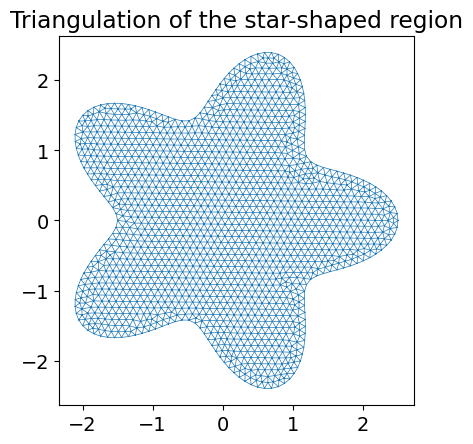

In [3]:
import pygmsh
import numpy as np

h_mesh = 0.1

N = 200
t_vals = np.linspace(0, 2*np.pi, N, endpoint=False)

# Convert to Cartesian
points = np.array([
    [star_curve_rad(t)*np.cos(t), star_curve_rad(t)*np.sin(t), 0.0]
    for t in t_vals
])

with pygmsh.geo.Geometry() as geom:
    # Add points
    pts = [geom.add_point(p, mesh_size=h_mesh) for p in points]

        # Close the loop
    pts.append(pts[0])

    # Create spline
    curve = geom.add_spline(pts)

    # Create surface
    loop = geom.add_curve_loop([curve])
    surface = geom.add_plane_surface(loop)

    # Generate mesh
    mesh = geom.generate_mesh()

# mesh.points → coordinates
# mesh.cells_dict["triangle"] → connectivity
tri = mesh.cells_dict["triangle"]
pts = mesh.points[:, :2]  # ignore z

plt.figure()
plt.triplot(pts[:,0], pts[:,1], tri,linewidth = 0.5)
# plt.scatter(pts[Bdry,0],pts[Bdry,1],c = 'red')
plt.gca().set_aspect('equal')
plt.title("Triangulation of the star-shaped region")


Npts = 1838, Ntri = 3110


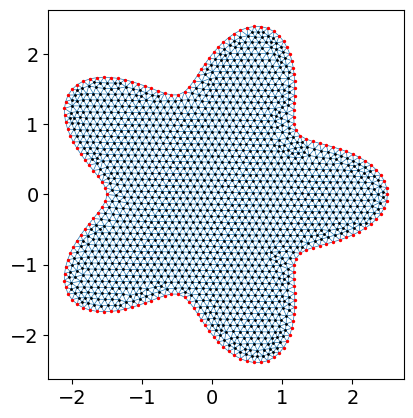

In [4]:
# Find boundary nodes and interior nodes
Npts = np.size(pts,axis = 0)
Ntri = np.size(tri,axis = 0)
print(f"Npts = {Npts}, Ntri = {Ntri}")

Nedges = Ntri*3
edges = np.zeros((Nedges,2),dtype = int)
for j in range(Ntri):
    t = tri[j,:]
    edges[3*j,:] = np.sort(np.array([t[0],t[1]]))
    edges[3*j+1,:] = np.sort(np.array([t[0],t[2]]))
    edges[3*j+2,:] = np.sort(np.array([t[1],t[2]]))

# Indices of boundary points
unique_edges, counts = np.unique(edges, axis=0, return_counts=True)
ind = np.argwhere(counts == 1)
Bdry = np.unique(unique_edges[ind,:].ravel())

# Indices of interior points
# Note that pts contains not only mesh points 
# but also points on the boundary curve that did not become part of the mesh
mesh_pts = np.unique(unique_edges.ravel())
Interior = np.setdiff1d(mesh_pts,Bdry)

plt.figure()
plt.triplot(pts[:,0], pts[:,1], tri,linewidth = 0.5)
plt.scatter(pts[Bdry,0],pts[Bdry,1],s = 2, c = 'red')
# plt.scatter(pts[:,0],pts[:,1],s = 0.5, c = 'blue')
plt.scatter(pts[Interior,0],pts[Interior,1],s = 1, c = 'black')
plt.gca().set_aspect('equal')


In [5]:
dt = 2*np.pi/N
t_bdry = np.linspace(0, 2*np.pi, N, endpoint=False)

#computing G, speed, norms, and boundary function values
G = np.array([get_point(t) for t in t_bdry])
normals = np.array([star_curve_normal(t) for t in t_bdry])
speeds = np.array([star_curve_speed(t) for t in t_bdry])
f = np.array([bdry_func(t) for t in t_bdry])

# BIE matrix assembly
A = np.zeros((N, N))
for i in range(N):
    for j in range(N):
        if i != j:
            diff = G[i] - G[j]
            dist_sq = np.sum(diff**2)
            
            dot_prod = np.dot(normals[j], diff)
            kernel = (1.0 / (2 * np.pi)) * (dot_prod / dist_sq)
            A[i, j] = kernel * speeds[j] * dt
            
    A[i, i] = -1.0 - np.sum(A[i, :]) 

sigma = np.linalg.solve(A, f) #solve sigma = A^{-1}b

In [6]:
from scipy.interpolate import CubicSpline

#discretize near boundary
N_fine = 10000
dt_fine = 2*np.pi/N_fine
t_fine = np.linspace(0, 2*np.pi, N_fine, endpoint=False)

cs = CubicSpline(np.append(t_bdry, 2*np.pi), np.append(sigma, sigma[0]), bc_type='periodic') # cubic interpolation
sigma_fine = cs(t_fine)

G_fine = np.array([get_point(t) for t in t_fine])
normals_fine = np.array([star_curve_normal(t) for t in t_fine])
speeds_fine = np.array([star_curve_speed(t) for t in t_fine])

In [7]:
u_approx = np.zeros(len(Interior))
u_exact = np.zeros(len(Interior))

max_step = np.max(speeds)*dt
threshold_dist = 3.0*max_step

for idx, pt_idx in enumerate(Interior):
    target = pts[pt_idx]
    
    r_target = np.linalg.norm(target)
    t_target = np.arctan2(target[1], target[0])
    u_exact[idx] = exact_sol(r_target, t_target)
    
    min_dist = np.min(np.linalg.norm(G - target, axis=1)) # dist to boundary pt
    
    if min_dist < threshold_dist:
        diff = target - G_fine
        dist_sq = np.sum(diff**2, axis=1)
        dot_prod = np.sum(normals_fine * diff, axis=1)
        kernel = (1.0 /(2*np.pi))*(dot_prod/dist_sq)
        u_approx[idx] = np.sum(kernel*sigma_fine*speeds_fine*dt_fine)
    else:
        diff = target - G
        dist_sq = np.sum(diff**2, axis=1)
        dot_prod = np.sum(normals * diff, axis=1)
        kernel = (1.0 / (2*np.pi))*(dot_prod/dist_sq)
        u_approx[idx] = np.sum(kernel*sigma*speeds*dt)

# calculate errors
errors = np.abs(u_approx - u_exact)
max_error = np.max(errors)

print(f"Maximal absolute error over interior points: {max_error:.4e}")

if max_error < 1e-4:
    print("Error requirement met.")
else:
    print("Error requirement not met.")

Maximal absolute error over interior points: 2.7286e-05
Error requirement met.


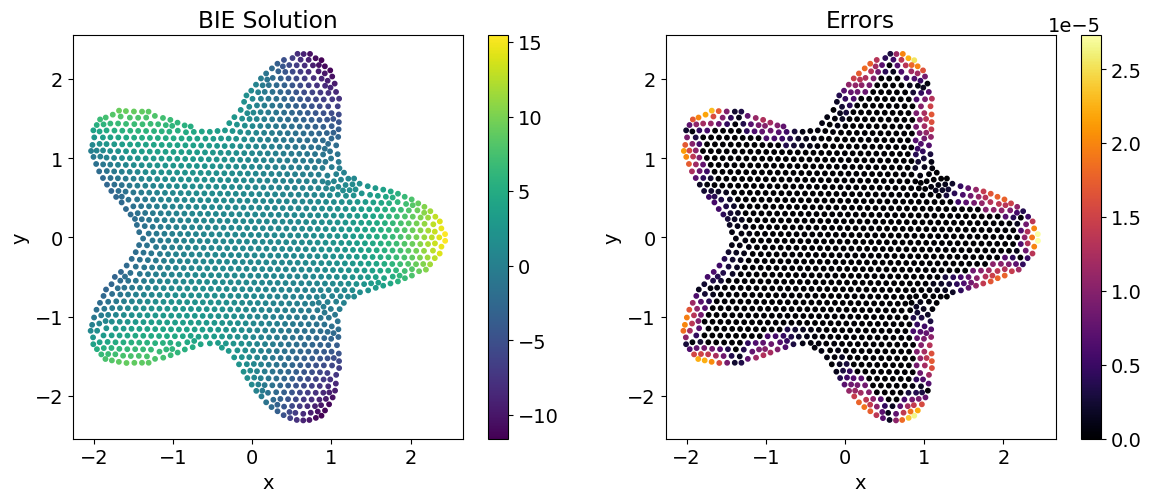

In [8]:
#plotting
fig = plt.figure(figsize=(12, 5))

#solution
ax1 = fig.add_subplot(121)
scatter1 = ax1.scatter(pts[Interior, 0], pts[Interior, 1], c=u_approx, cmap='viridis', s=10)
plt.colorbar(scatter1, ax=ax1)
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_aspect('equal')
ax1.set_title("BIE Solution")

#heatmap
ax2 = fig.add_subplot(122)
scatter = ax2.scatter(pts[Interior, 0], pts[Interior, 1], c=errors, cmap='inferno', s=10)
plt.colorbar(scatter, ax=ax2)
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_aspect('equal')
ax2.set_title("Errors")

plt.tight_layout()
plt.show()

In [9]:
#problem 3
import pygmsh

def exact_sol_ext(r, t):
    return (r**-3) * np.cos(3*t) + np.log(r)

def bdry_func_ext(t):
    r = star_curve_rad(t)
    return exact_sol_ext(r, t)

h_mesh = 0.1

t_vals = np.linspace(0, 2*np.pi, N, endpoint=False)
star_pts = np.array([
    [star_curve_rad(t)*np.cos(t), star_curve_rad(t)*np.sin(t), 0.0]
    for t in t_vals
])

with pygmsh.geo.Geometry() as geom:
    L = 4.0
    sq_pts = [
        geom.add_point([-L, -L, 0.0], mesh_size=h_mesh*3),
        geom.add_point([ L, -L, 0.0], mesh_size=h_mesh*3),
        geom.add_point([ L,  L, 0.0], mesh_size=h_mesh*3),
        geom.add_point([-L,  L, 0.0], mesh_size=h_mesh*3)
    ]
    sq_lines = [geom.add_line(sq_pts[i], sq_pts[(i+1)%4]) for i in range(4)]
    outer_loop = geom.add_curve_loop(sq_lines)
    
    hole_pts = [geom.add_point(p, mesh_size=h_mesh) for p in star_pts]
    hole_pts.append(hole_pts[0])
    hole_curve = geom.add_spline(hole_pts)
    inner_loop = geom.add_curve_loop([hole_curve])
    
    surface = geom.add_plane_surface(outer_loop, holes=[inner_loop])
    mesh = geom.generate_mesh()

pts_ext = mesh.points[:, :2]

r_pts = np.linalg.norm(pts_ext, axis=1)
t_pts = np.arctan2(pts_ext[:,1], pts_ext[:,0])
r_star = star_curve_rad(t_pts)

Eval_pts = np.where(np.abs(r_pts - r_star) > 1e-3)[0]

print(f"Total mesh points: {len(pts_ext)}, Points for evaluation: {len(Eval_pts)}")

Total mesh points: 2195, Points for evaluation: 1830


In [10]:
dt = 2*np.pi/N
t_bdry = np.linspace(0, 2*np.pi, N, endpoint=False)

G = np.array([get_point(t) for t in t_bdry])
normals = np.array([star_curve_normal(t) for t in t_bdry])
speeds = np.array([star_curve_speed(t) for t in t_bdry])
f_ext = np.array([bdry_func_ext(t) for t in t_bdry])

A = np.zeros((N, N))

for i in range(N):
    for j in range(N):
        if i != j:
            diff = G[i] - G[j]
            dist_sq = np.sum(diff**2)
            dot_prod = np.dot(normals[j], diff)
            kernel = (1.0 /(2*np.pi))*(dot_prod/dist_sq)
            A[i, j] = kernel * speeds[j]*dt
            
    A[i, i] = -np.sum(A[i, :])

for i in range(N):
    r_i = np.linalg.norm(G[i])
    for j in range(N):
        A[i, j] += np.log(r_i)*speeds[j]*dt

sigma_ext = np.linalg.solve(A, f_ext)


from scipy.interpolate import CubicSpline
N_fine = 10000
dt_fine = 2*np.pi/N_fine
t_fine = np.linspace(0, 2*np.pi, N_fine, endpoint=False)

cs_ext = CubicSpline(np.append(t_bdry, 2*np.pi), np.append(sigma_ext, sigma_ext[0]), bc_type='periodic')
sigma_fine_ext = cs_ext(t_fine)

G_fine = np.array([get_point(t) for t in t_fine])
normals_fine = np.array([star_curve_normal(t) for t in t_fine])
speeds_fine = np.array([star_curve_speed(t) for t in t_fine])

In [11]:
u_approx = np.zeros(len(Eval_pts))
u_exact = np.zeros(len(Eval_pts))

threshold_dist = 3.0*np.max(speeds)*dt

for idx, pt_idx in enumerate(Eval_pts):
    target = pts_ext[pt_idx]
    r_target = np.linalg.norm(target)
    t_target = np.arctan2(target[1], target[0])
    
    u_exact[idx] = exact_sol_ext(r_target, t_target)
    min_dist = np.min(np.linalg.norm(G - target, axis=1))
    
    if min_dist < threshold_dist:
        diff = target - G_fine
        dist_sq = np.sum(diff**2, axis=1)
        dot_prod = np.sum(normals_fine*diff, axis=1)
        kernel = (1.0 /(2*np.pi))*(dot_prod/dist_sq)
        
        dlp = np.sum(kernel*sigma_fine_ext*speeds_fine*dt_fine)
        log_term = np.log(r_target)*np.sum(sigma_fine_ext*speeds_fine*dt_fine)
        u_approx[idx] = dlp + log_term
    else:
        diff = target - G
        dist_sq = np.sum(diff**2, axis=1)
        dot_prod = np.sum(normals*diff, axis=1)
        kernel = (1.0 /(2*np.pi))*(dot_prod/dist_sq)
        
        dlp = np.sum(kernel*sigma_ext*speeds*dt)
        log_term = np.log(r_target) * np.sum(sigma_ext*speeds*dt)
        u_approx[idx] = dlp + log_term

errors = np.abs(u_approx - u_exact)
print(f"Maximal exterior absolute error: {np.max(errors):.4e}")

Maximal exterior absolute error: 8.5428e-07


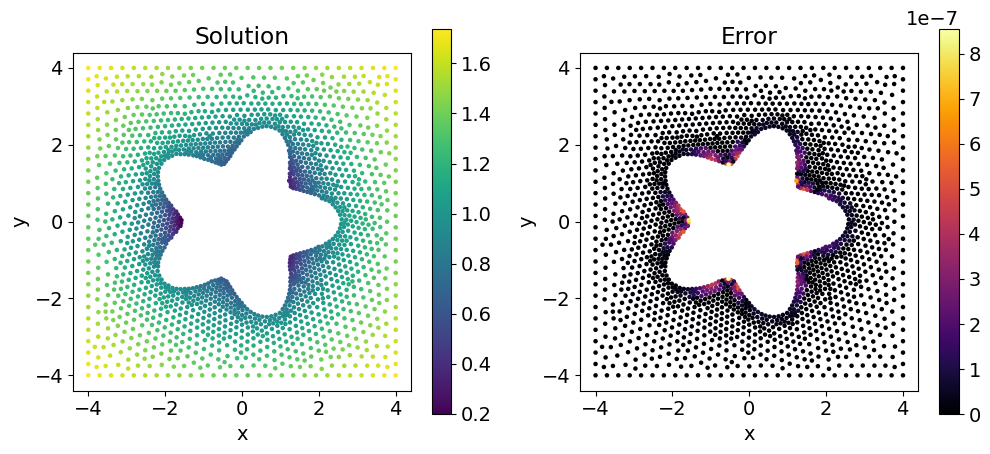

In [12]:
#plotting
fig = plt.figure(figsize=(12, 5))

#pde solution
ax1 = fig.add_subplot(121)
scatter1 = ax1.scatter(pts_ext[Eval_pts, 0], pts_ext[Eval_pts, 1], c=u_approx, cmap='viridis', s=5)
plt.colorbar(scatter1, ax=ax1)
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_title("Solution")
ax1.set_aspect('equal')

#error
ax2 = fig.add_subplot(122)
scatter2 = ax2.scatter(pts_ext[Eval_pts, 0], pts_ext[Eval_pts, 1], c=errors, cmap='inferno', s=5)
plt.colorbar(scatter2, ax=ax2)
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_title(f"Error")
ax2.set_aspect('equal')
plt.show()